# NPL Project

In [4]:
# 📚 Basic Libraries
import pandas as pd
import numpy as np
import warnings

# 📊 Visualizations
import matplotlib as plt
import seaborn as sns
import plotly as px

# 🤖 NLP Libraries
import nltk # natural language toolkit

# 🧮 Metrics
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, f1_score

### Data Extraction

In [5]:
data = pd.read_csv("/content/training_data.csv", header=None, names=['label', 'text'], delimiter='\t')
df = data.copy()

In [6]:
df.head()

,label,text
0,0,donald trump sends out embarrassing new year‚s...
1,0,drunk bragging trump staffer started russian c...
2,0,sheriff david clarke becomes an internet joke ...
3,0,trump is so obsessed he even has obama‚s name ...
4,0,pope francis just called out donald trump duri...


In [7]:
df.shape

(34152, 2)

In [8]:
unique_labels = df['label'].unique()
print(unique_labels)

[0 1]


### Test-train Split

In [9]:
from sklearn.model_selection import train_test_split
X = df['text']
y = df['label']       #target

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2,random_state=42, stratify=y)        # stratify=y  ensures balanced labels

In [10]:
X_train.head()

,text
6851,republicans punish georgia governor for refusi...
17313,father of soldier slain in niger defends presi...
22435,south dakota's governor vetoes loosening of co...
29488,turkey's erdogan says will take jerusalem reso...
6625,bill maher insults trump‚s supposed masculinit...


## Data Preprocessing

### 1.1 Tokenization

In [11]:
from nltk.tokenize import word_tokenize, sent_tokenize

def tokenize_text(text):
    return word_tokenize(text)

In [14]:
X_train = X_train.apply(tokenize_text)
X_test = X_test.apply(tokenize_text)

In [15]:
X_train.head()

,text
6851,"[republicans, punish, georgia, governor, for, ..."
17313,"[father, of, soldier, slain, in, niger, defend..."
22435,"[south, dakota, 's, governor, vetoes, loosenin..."
29488,"[turkey, 's, erdogan, says, will, take, jerusa..."
6625,"[bill, maher, insults, trump‚s, supposed, masc..."


### 1.2 Lowercasing and punctuation

In [16]:
import re

def clean_text(text):

    # Remove special characters
    text = re.sub(r'[^a-zA-Z0-9\s]', ' ', str(text))     # ^ inside a [] means negation   # a-zA-Z0-9  all letters and numbers    #\s  space

    # Remove single characters
    text = re.sub(r'\b[a-zA-Z]\b', '', str(text))        # \b  limit of a word

    # Remove multiple spaces
    text = re.sub(r'\s+', ' ', str(text)).strip()

    # Lowercase
    text = text.lower()

    return text

In [17]:
X_train = X_train.apply(clean_text)
X_test = X_test.apply(clean_text)

In [18]:
X_train.head()

,text
6851,republicans punish georgia governor for refusi...
17313,father of soldier slain in niger defends presi...
22435,south dakota governor vetoes loosening of conc...
29488,turkey erdogan says will take jerusalem resolu...
6625,bill maher insults trump supposed masculinity ...


### 1.3 Stop words

In [21]:
from nltk.corpus import stopwords

stop_words = set(stopwords.words('english'))

def remove_stopwords(text):
    tokens = word_tokenize(text)  # tokenize again because after cleaning it is not separated words
    filtered_tokens = [word for word in tokens if word not in stop_words]
    return " ".join(filtered_tokens)  # return a string to use later

In [22]:
X_train = X_train.apply(remove_stopwords)
X_test = X_test.apply(remove_stopwords)

In [23]:
X_train.head()

,text
6851,republicans punish georgia governor refusing l...
17313,father soldier slain niger defends president t...
22435,south dakota governor vetoes loosening conceal...
29488,turkey erdogan says take jerusalem resolution ...
6625,bill maher insults trump supposed masculinity ...


## Text Vectors

### Lemmatization

In [24]:
from nltk.stem import WordNetLemmatizer

lemmatizer = WordNetLemmatizer()

def lemmatized_text(text):
    tokens = word_tokenize(text)

    cleaned_tokens = [lemmatizer.lemmatize(word) for word in tokens]

    return " ".join(cleaned_tokens)

In [27]:
X_train = X_train.apply(lemmatized_text)
X_test = X_test.apply(lemmatized_text)

In [28]:
X_train.head()

,text
6851,republican punish georgia governor refusing le...
17313,father soldier slain niger defends president t...
22435,south dakota governor veto loosening concealed...
29488,turkey erdogan say take jerusalem resolution g...
6625,bill maher insult trump supposed masculinity g...


### Bag of Words

In [29]:
from sklearn.feature_extraction.text import CountVectorizer

vectorizer_bag = CountVectorizer()

X_train_bag = vectorizer_bag.fit_transform(X_train)
X_test_bag = vectorizer_bag.transform(X_test)

### TF-IDF

In [30]:
from sklearn.feature_extraction.text import TfidfVectorizer

vectorizer_tf = TfidfVectorizer()

X_train_tf = vectorizer_tf.fit_transform(X_train)
X_test_tf = vectorizer_tf.transform(X_test)

In [31]:
# First Classifier: LogisticRegression

from sklearn.linear_model import LogisticRegression
lr = LogisticRegression()

lr.fit(X_train_tf, y_train)

# Predictions
y_train_pred = lr.predict(X_train_tf)
y_test_pred = lr.predict(X_test_tf)

# Evaluation
print("TRAIN ACCURACY:", round(accuracy_score(y_train, y_train_pred),3))
print("TEST ACCURACY:", round(accuracy_score(y_test, y_test_pred),3))

print("\nClassification Report (Test):")
print(classification_report(y_test, y_test_pred, zero_division=0))

print("\nConfusion Matrix (Test):")
print(confusion_matrix(y_test, y_test_pred))

TRAIN ACCURACY: 0.955
TEST ACCURACY: 0.931

Classification Report (Test):
              precision    recall  f1-score   support

           0       0.94      0.93      0.93      3515
           1       0.92      0.94      0.93      3316

    accuracy                           0.93      6831
   macro avg       0.93      0.93      0.93      6831
weighted avg       0.93      0.93      0.93      6831


Confusion Matrix (Test):
[[3252  263]
 [ 211 3105]]


## Optimization

We are going to use and experiment with the parameters of TF-IDF only

In [32]:
# Define a print results function, in case we need it

def evaluate_model(model, X_train_tf, X_test_tf, y_train, y_test):

    y_train_pred = model.predict(X_train_tf)
    y_test_pred = model.predict(X_test_tf)

    # Results
    print("TRAIN ACCURACY:", round(accuracy_score(y_train, y_train_pred),3))
    print("TEST ACCURACY:", round(accuracy_score(y_test, y_test_pred),3))

    print("\nClassification Report (Test):")
    print(classification_report(y_test, y_test_pred, zero_division=0))

    print("\nConfusion Matrix (Test):")
    print(confusion_matrix(y_test, y_test_pred))

Two TD-IDF configurations

In [33]:
# Basic one
vectorizer_tf = TfidfVectorizer()

X_train_tf = vectorizer_tf.fit_transform(X_train)
X_test_tf = vectorizer_tf.transform(X_test)

In [34]:
# High parameters one
vectorizer_tf2 = TfidfVectorizer(ngram_range=(1,2),max_df=0.8,min_df=5,max_features=5000)

X_train_tf2 = vectorizer_tf2.fit_transform(X_train)
X_test_tf2 = vectorizer_tf2.transform(X_test)

In [35]:
# Checking new vectorizer with LogisticRegression

lr = LogisticRegression()

lr.fit(X_train_tf2, y_train)

# Predictions
y_train_pred2 = lr.predict(X_train_tf2)
y_test_pred2 = lr.predict(X_test_tf2)

# Evaluation
print("TRAIN ACCURACY:", round(accuracy_score(y_train, y_train_pred2),3))
print("TEST ACCURACY:", round(accuracy_score(y_test, y_test_pred2),3))

print("\nClassification Report (Test):")
print(classification_report(y_test, y_test_pred2, zero_division=0))

print("\nConfusion Matrix (Test):")
print(confusion_matrix(y_test, y_test_pred2))

TRAIN ACCURACY: 0.95
TEST ACCURACY: 0.932

Classification Report (Test):
              precision    recall  f1-score   support

           0       0.94      0.93      0.93      3515
           1       0.92      0.94      0.93      3316

    accuracy                           0.93      6831
   macro avg       0.93      0.93      0.93      6831
weighted avg       0.93      0.93      0.93      6831


Confusion Matrix (Test):
[[3259  256]
 [ 206 3110]]


#### Different Classifiers

Because the accuracy betweeb the two vectorizers is similiar, we are trying only with the High parameters vectorizer

In [36]:
# First Classifier: LogisticRegression
lr = LogisticRegression()

lr.fit(X_train_tf2, y_train)

lr_pred = lr.predict(X_test_tf2)


In [37]:
# Second Classifier: Random Forest
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(n_estimators=200,max_depth=None,random_state=42)

rf.fit(X_train_tf2, y_train)

rf_pred = rf.predict(X_test_tf2)

In [38]:
# Third Classifier: Multinomial Naive Bayes
from sklearn.naive_bayes import MultinomialNB

nb = MultinomialNB(alpha=1.0)

nb.fit(X_train_tf2, y_train)

nb_pred = nb.predict(X_test_tf2)

Compare all models

In [39]:
print("Logistic Regression:", round(accuracy_score(y_test, lr_pred),3))
print("Random Forest:", round(accuracy_score(y_test, rf_pred),3))
print("Naive Bayes:", round(accuracy_score(y_test, nb_pred),3))

Logistic Regression: 0.932
Random Forest: 0.914
Naive Bayes: 0.926


## Hyperparameter Tuning

We're going to use GridSearchCV

In [40]:
from sklearn.model_selection import GridSearchCV

# Base model
rf = RandomForestClassifier(random_state=42)

# Hyperparameters
param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [None, 10, 20],
    'min_samples_split': [2, 5]
}

# Grid Search
grid_search = GridSearchCV(
    rf,
    param_grid,
    cv=5,              # cross validation
    scoring='accuracy',
    n_jobs=-1
)

grid_search.fit(X_train_tf2, y_train)

# Best model found
best_rf = grid_search.best_estimator_

print("Best RF parameters:", grid_search.best_params_)

# Final evaluation
rf_best_pred = best_rf.predict(X_test_tf2)

Best RF parameters: {'max_depth': None, 'min_samples_split': 5, 'n_estimators': 200}


In [41]:
nb = MultinomialNB()

param_grid_nb = {
    'alpha': [0.1, 0.5, 1.0, 2.0]
}

grid_nb = GridSearchCV(
    nb,
    param_grid_nb,
    cv=5,
    scoring='accuracy',
    n_jobs=-1
)

grid_nb.fit(X_train_tf2, y_train)

best_nb = grid_nb.best_estimator_

print("Best NB parameters:", grid_nb.best_params_)

nb_best_pred = best_nb.predict(X_test_tf2)

Best NB parameters: {'alpha': 0.1}


Compare all models, after hyperparameter tuning

In [42]:
print("Logistic Regression:", round(accuracy_score(y_test, lr_pred),3))
print("Random Forest:", round(accuracy_score(y_test, rf_pred),3))
print("Random Forest Tuned:", round(accuracy_score(y_test, rf_best_pred),3))
print("Naive Bayes:", round(accuracy_score(y_test, nb_pred),3))
print("Naive Bayes Tuned:", round(accuracy_score(y_test, nb_best_pred),3))

Logistic Regression: 0.932
Random Forest: 0.914
Random Forest Tuned: 0.914
Naive Bayes: 0.926
Naive Bayes Tuned: 0.927


# Chose the best performing model

We will check the best values for the vectorizer and the three classifiers

In [43]:
from sklearn.pipeline import Pipeline

pipeline = Pipeline([
    ("vec", TfidfVectorizer()),
    ("clf", LogisticRegression())  # placeholder
])

param_grid = [
    # Logistic Regression
    {
        "clf": [LogisticRegression(max_iter=1000)],
        "vec__ngram_range": [(1,1), (1,2)],
        "vec__max_df": [0.9, 0.95],
        "vec__min_df": [2,3,5],
        "vec__max_features": [100000, 200000],
        "clf__C": [0.1, 1, 10]
    },

    # Random Forest
    {
        "clf": [RandomForestClassifier(random_state=42)],
        "vec__ngram_range": [(1,1), (1,2)],
        "vec__max_df": [0.9, 0.95],
        "vec__min_df": [2,3,5],
        "vec__max_features": [100000, 200000],
        "clf__n_estimators": [200, 500],
        "clf__max_depth": [None, 20]
    },

    # MultinomialNB
    {
        "clf": [MultinomialNB()],
        "vec__ngram_range": [(1,1), (1,2)],
        "vec__max_df": [0.9, 0.95],
        "vec__min_df": [2,3,5],
        "vec__max_features": [100000, 200000],
        "clf__alpha": [0.1, 1.0]
    }
]

grid = GridSearchCV(
    pipeline,
    param_grid,
    cv=3,
    scoring="f1_weighted",
    n_jobs=-1,
    verbose=2
)

grid.fit(X_train, y_train)

print("BEST MODEL:", grid.best_estimator_)
print("BEST PARAMS:", grid.best_params_)
print("BEST F1:", grid.best_score_)

Fitting 3 folds for each of 216 candidates, totalling 648 fits


/usr/local/lib/python3.12/dist-packages/joblib/externals/loky/process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


BEST MODEL: Pipeline(steps=[('vec',
                 TfidfVectorizer(max_df=0.9, max_features=100000, min_df=2,
                                 ngram_range=(1, 2))),
                ('clf', LogisticRegression(C=10, max_iter=1000))])
BEST PARAMS: {'clf': LogisticRegression(max_iter=1000), 'clf__C': 10, 'vec__max_df': 0.9, 'vec__max_features': 100000, 'vec__min_df': 2, 'vec__ngram_range': (1, 2)}
BEST F1: 0.9347477841479553


We will create a function to test the 3 models with different TF-IDF parameters combinations

In [44]:
#Best parameters after Grid Search

# LogisticRegression(C=10, max_iter=1000)
# Best RF parameters: {'max_depth': None, 'min_samples_split': 5, 'n_estimators': 200}
# Best NB parameters: {'alpha': 0.5}

In [45]:
def run_full_experiment(configs):

    results = []

    for config in configs:                  #Later define configs

        print("="*50)
        print("TF-IDF Config:", config)

        # Vectorizer that will get the parameters
        vectorizer = TfidfVectorizer(
            ngram_range=config.get("ngram", (1,1)),
            max_df=config.get("max_df", 1.0),
            min_df=config.get("min_df", 1),
            max_features=config.get("max_features", None)
        )

        # Vectorization
        X_train_vec = vectorizer.fit_transform(X_train)
        X_test_vec = vectorizer.transform(X_test)

        # Define models with the best parameters from GridSearch
        models = {
            "LogisticRegression": LogisticRegression(max_iter=1000, C=10),
            "RandomForest": RandomForestClassifier(n_estimators=200, max_depth=None, min_samples_split=5, random_state=42),
            "MultinomialNB": MultinomialNB(alpha=0.5)
        }

        # Train and evaluate each model
        for model_name, model in models.items():

            model.fit(X_train_vec, y_train)

            y_train_pred = model.predict(X_train_vec)
            y_test_pred = model.predict(X_test_vec)

            train_acc = accuracy_score(y_train, y_train_pred)
            test_acc = accuracy_score(y_test, y_test_pred)

            train_f1 = f1_score(y_train, y_train_pred, average='weighted')
            test_f1 = f1_score(y_test, y_test_pred, average='weighted')

            gap = train_acc - test_acc

            results.append({
                "model": model_name,
                "ngram": config.get("ngram", (1,1)),
                "max_df": config.get("max_df", 1.0),
                "min_df": config.get("min_df", 1),
                "max_features": config.get("max_features", None),
                "train_acc": train_acc,
                "test_acc": test_acc,
                "train_f1": train_f1,
                "test_f1": test_f1,
                "gap": gap
            })

    results_df = pd.DataFrame(results)

    # Sort by best accuracy
    results_df = results_df.sort_values(by="test_acc", ascending=False)

    return results_df

In [46]:
#Best parameters for vectorizer after Grid Search

# max_df: 0.9, max_features: 100000, min_df: 2, ngram_range: (1, 2)

In [47]:
configs = [
    {"ngram": (1,1)},
    {"ngram": (1,2)},
    {"ngram": (1,2), "max_features": 5000},
    {"ngram": (1,2), "max_df": 0.8, "min_df": 5},
    {"ngram": (1,2), "max_df": 0.9, "min_df": 2,"max_features": 100000}     #Supposed to be best model
]

In [48]:
results_table = run_full_experiment(configs)

print("\nFINAL RESULTS:")
print(results_table)

TF-IDF Config: {'ngram': (1, 1)}
TF-IDF Config: {'ngram': (1, 2)}
TF-IDF Config: {'ngram': (1, 2), 'max_features': 5000}
TF-IDF Config: {'ngram': (1, 2), 'max_df': 0.8, 'min_df': 5}
TF-IDF Config: {'ngram': (1, 2), 'max_df': 0.9, 'min_df': 2, 'max_features': 100000}

FINAL RESULTS:
                 model   ngram  max_df  min_df  max_features  train_acc  \
3   LogisticRegression  (1, 2)     1.0       1           NaN   0.998573   
12  LogisticRegression  (1, 2)     0.9       2      100000.0   0.995718   
5        MultinomialNB  (1, 2)     1.0       1           NaN   0.990008   
14       MultinomialNB  (1, 2)     0.9       2      100000.0   0.965741   
9   LogisticRegression  (1, 2)     0.8       5           NaN   0.984664   
6   LogisticRegression  (1, 2)     1.0       1        5000.0   0.968522   
0   LogisticRegression  (1, 1)     1.0       1           NaN   0.980638   
11       MultinomialNB  (1, 2)     0.8       5           NaN   0.946268   
8        MultinomialNB  (1, 2)     1.0    

Checking with uncleaned data

In [49]:
df3 = data.copy()
X3 = df3['text']
y3 = df3['label']       #target

X3_train, X3_test, y3_train, y3_test = train_test_split(X3, y3, test_size=0.2,random_state=42, stratify=y3)        # stratify=y  ensures balanced labels

In [50]:
def run_full_experiment_unc(configs):

    results = []

    for config in configs:                  #Later define configs

        print("="*50)
        print("TF-IDF Config:", config)

        # Vectorizer that will get the parameters
        vectorizer = TfidfVectorizer(
            ngram_range=config.get("ngram", (1,1)),
            max_df=config.get("max_df", 1.0),
            min_df=config.get("min_df", 1),
            max_features=config.get("max_features", None)
        )

        # Vectorization
        X_train_vec = vectorizer.fit_transform(X3_train)
        X_test_vec = vectorizer.transform(X3_test)

        # Define models with the best parameters from GridSearch
        models = {
            "LogisticRegression": LogisticRegression(max_iter=1000, C=10),
            "RandomForest": RandomForestClassifier(n_estimators=200, max_depth=None, min_samples_split=5, random_state=42),
            "MultinomialNB": MultinomialNB(alpha=0.5)
        }

        # Train and evaluate each model
        for model_name, model in models.items():

            model.fit(X_train_vec, y3_train)

            y_train_pred = model.predict(X_train_vec)
            y_test_pred = model.predict(X_test_vec)

            train_acc = accuracy_score(y3_train, y_train_pred)
            test_acc = accuracy_score(y3_test, y_test_pred)

            train_f1 = f1_score(y3_train, y_train_pred, average='weighted')
            test_f1 = f1_score(y3_test, y_test_pred, average='weighted')

            gap = train_acc - test_acc

            results.append({
                "model": model_name,
                "ngram": config.get("ngram", (1,1)),
                "max_df": config.get("max_df", 1.0),
                "min_df": config.get("min_df", 1),
                "max_features": config.get("max_features", None),
                "train_acc": train_acc,
                "test_acc": test_acc,
                "train_f1": train_f1,
                "test_f1": test_f1,
                "gap": gap
            })

    results_df = pd.DataFrame(results)

    # Sort by best accuracy
    results_df = results_df.sort_values(by="test_acc", ascending=False)

    return results_df

In [51]:
results_table_unc = run_full_experiment_unc(configs)

print("\nFINAL RESULTS:")
print(results_table_unc)

TF-IDF Config: {'ngram': (1, 1)}
TF-IDF Config: {'ngram': (1, 2)}
TF-IDF Config: {'ngram': (1, 2), 'max_features': 5000}
TF-IDF Config: {'ngram': (1, 2), 'max_df': 0.8, 'min_df': 5}
TF-IDF Config: {'ngram': (1, 2), 'max_df': 0.9, 'min_df': 2, 'max_features': 100000}

FINAL RESULTS:
                 model   ngram  max_df  min_df  max_features  train_acc  \
3   LogisticRegression  (1, 2)     1.0       1           NaN   0.999597   
12  LogisticRegression  (1, 2)     0.9       2      100000.0   0.997621   
0   LogisticRegression  (1, 1)     1.0       1           NaN   0.990410   
9   LogisticRegression  (1, 2)     0.8       5           NaN   0.991911   
14       MultinomialNB  (1, 2)     0.9       2      100000.0   0.970572   
6   LogisticRegression  (1, 2)     1.0       1        5000.0   0.979100   
5        MultinomialNB  (1, 2)     1.0       1           NaN   0.988690   
11       MultinomialNB  (1, 2)     0.8       5           NaN   0.953918   
1         RandomForest  (1, 1)     1.0    

The results are almost 1% better in every case with uncleaned data

# Transformers

In [52]:
# load pretrained model
# load tokenizer
# tokenize train and test data (format as string)
# setting up training_args
# train the model

In [53]:
import torch
from transformers import AutoModelForSequenceClassification, AutoTokenizer
from transformers import Trainer, TrainingArguments
from datasets import Dataset

No need to do the cleaning with transformers

In [54]:
df2 = data.copy()

In [55]:
X2= df2['text']
y2 = df2['label']       #target

X2_train, X2_test, y2_train, y2_test = train_test_split(X2, y2, test_size=0.2,random_state=42, stratify=y)        # stratify=y  ensures balanced labels

In [56]:
# load pretrained model
model = AutoModelForSequenceClassification.from_pretrained("distilbert-base-uncased",num_labels=2)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_transform.bias    | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
classifier.bias         | MISSING    | 
pre_classifier.bias     | MISSING    | 
classifier.weight       | MISSING    | 
pre_classifier.weight   | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


In [57]:
# load tokenizer
tokenizer = AutoTokenizer.from_pretrained("distilbert-base-uncased")

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

In [58]:
# tokenize train and test data
def tokenize_function(example):
    return tokenizer(
        example["text"],
        padding= 'max_length',
        truncation=True,
        max_length=256
    )

train_dataset = Dataset.from_dict({
    "text": X2_train.tolist(),
    "label": y2_train.tolist()
})

test_dataset = Dataset.from_dict({
    "text": X2_test.tolist(),
    "label": y2_test.tolist()
})

train_dataset = train_dataset.map(tokenize_function, batched=True)
test_dataset = test_dataset.map(tokenize_function, batched=True)

Map:   0%|          | 0/27321 [00:00<?, ? examples/s]

Map:   0%|          | 0/6831 [00:00<?, ? examples/s]

In [59]:
# setting up training_args
training_args = TrainingArguments(
    output_dir="./results",

    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,

    num_train_epochs=3,
    learning_rate=5e-5,
    weight_decay=0.01,
    max_grad_norm=1.0,

    logging_strategy="steps",
    logging_steps=50,
    eval_strategy="steps",
    eval_steps=500,

    save_strategy="steps",
    save_steps=500,
    save_total_limit=3,

    load_best_model_at_end=True,
    metric_for_best_model="eval_loss",
    greater_is_better=False,



    report_to="none",
    seed=42,
)

In [60]:
# train the model
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=test_dataset
)

trainer.train()

Step,Training Loss,Validation Loss
500,0.057107,0.118467
1000,0.056838,0.089836
1500,0.109725,0.092588
2000,0.016028,0.080465
2500,0.045169,0.070897
3000,0.036266,0.062517
3500,0.006538,0.087136
4000,0.017387,0.093226
4500,0.000205,0.092841
5000,0.000257,0.088225


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['distilbert.embeddings.LayerNorm.weight', 'distilbert.embeddings.LayerNorm.bias'].
There were unexpected keys in the checkpoint model loaded: ['distilbert.embeddings.LayerNorm.beta', 'distilbert.embeddings.LayerNorm.gamma'].


TrainOutput(global_step=5124, training_loss=0.051577143104286, metrics={'train_runtime': 2441.4166, 'train_samples_per_second': 33.572, 'train_steps_per_second': 2.099, 'total_flos': 5428712698020864.0, 'train_loss': 0.051577143104286, 'epoch': 3.0})

In [61]:
# Results after running transformer (stored to no t run it again)

# TrainOutput(global_step=5124, training_loss=0.05327914945365371,
# metrics={'train_runtime': 47229.2933, 'train_samples_per_second': 1.735, 'train_steps_per_second': 0.108, 'total_flos': 5428712698020864.0, 'train_loss': 0.05327914945365371, 'epoch': 3.0})

In [62]:
#evaluate
trainer.evaluate()

{'eval_loss': 0.06251436471939087,
 'eval_runtime': 54.5323,
 'eval_samples_per_second': 125.265,
 'eval_steps_per_second': 7.83,
 'epoch': 3.0}

In [63]:
pred = trainer.predict(test_dataset)
y_pred = np.argmax(pred.predictions, axis=-1)
y_true = pred.label_ids

In [64]:
# Evaluation
print("TEST ACCURACY:", round(accuracy_score(y_true, y_pred),3))

print("\nClassification Report (Test):")
print(classification_report(y_true, y_pred, zero_division=0))

print("\nConfusion Matrix (Test):")
print(confusion_matrix(y_true, y_pred))

TEST ACCURACY: 0.984

Classification Report (Test):
              precision    recall  f1-score   support

           0       0.99      0.98      0.98      3515
           1       0.98      0.98      0.98      3316

    accuracy                           0.98      6831
   macro avg       0.98      0.98      0.98      6831
weighted avg       0.98      0.98      0.98      6831


Confusion Matrix (Test):
[[3458   57]
 [  50 3266]]


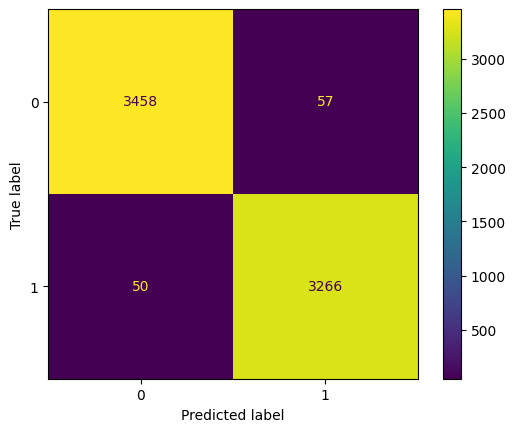

In [65]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

disp = ConfusionMatrixDisplay(confusion_matrix(y_true, y_pred))

disp.plot()

plt.show()

# Best Model

Recap of the best model in order to use it in the other dataset

In [66]:
import joblib

best_model = grid.best_estimator_

# Save modelo
joblib.dump(best_model, "model_fake_new.pkl")

print("Model saved")

Model saved


## Test the model in the testing dataset

In [71]:
new_data = pd.read_csv("/content/testing_data.csv", header=None, names=['label', 'text'], delimiter='\t')
new_df = new_data.copy()

In [72]:
new_df.head()

,label,text
0,2,copycat muslim terrorist arrested with assault...
1,2,wow! chicago protester caught on camera admits...
2,2,germany's fdp look to fill schaeuble's big shoes
3,2,mi school sends welcome back packet warning ki...
4,2,u.n. seeks 'massive' aid boost amid rohingya '...


We've seen that the model works better with uncleaned data

In [73]:
predictions = best_model.predict(new_df["text"])

In [74]:
new_df["label"] = predictions

In [75]:
new_df.to_csv("new_traning_data.csv", index=False)

In [77]:
new_df.head()

,label,text
0,0,copycat muslim terrorist arrested with assault...
1,0,wow! chicago protester caught on camera admits...
2,1,germany's fdp look to fill schaeuble's big shoes
3,0,mi school sends welcome back packet warning ki...
4,1,u.n. seeks 'massive' aid boost amid rohingya '...
